# E-Commerce Customer Intelligence System

## Project Overview
This notebook builds an end-to-end analytics and AI solution for an e-commerce company, starting from a raw SQLite database and ending with a deployed Streamlit app.


## Task A: Database Inspection and Cleaning

In [2]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = "ecommerce_hackathon.db"
CLEAN_DB_PATH = "ecommerce_clean.db"
TABLES = ["customers", "products", "orders", "reviews"]

conn = sqlite3.connect(DB_PATH)
raw = {t: pd.read_sql(f"SELECT * FROM {t}", conn) for t in TABLES}

![ER Diagram](er_diagram.png)

In [3]:
def quality_report(df, name):
    print(f"\n===== {name} | shape: {df.shape}")
    print("Columns:", list(df.columns))
    missing = df.isna().sum()
    print("Missing values:\n", missing[missing > 0])
    print("Duplicate rows:", df.duplicated().sum())
    print("Duplicate IDs:", df.iloc[:, 0].duplicated().sum())

for t in TABLES:
    quality_report(raw[t], t)


===== customers | shape: (8000, 9)
Columns: ['customer_id', 'customer_name', 'age', 'gender', 'city', 'signup_date', 'membership_type', 'email', 'phone']
Missing values:
 age    100
dtype: int64
Duplicate rows: 0
Duplicate IDs: 0

===== products | shape: (1000, 6)
Columns: ['product_id', 'product_name', 'category', 'brand', 'unit_price', 'stock_quantity']
Missing values:
 brand    20
dtype: int64
Duplicate rows: 0
Duplicate IDs: 0

===== orders | shape: (65000, 10)
Columns: ['order_id', 'customer_id', 'product_id', 'order_date', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'returned']
Missing values:
 payment_method    55
delivery_days     40
dtype: int64
Duplicate rows: 0
Duplicate IDs: 0

===== reviews | shape: (26000, 6)
Columns: ['review_id', 'customer_id', 'product_id', 'review_date', 'rating', 'review_text']
Missing values:
 review_text    48
dtype: int64
Duplicate rows: 0
Duplicate IDs: 0


In [8]:
MESSY_TEXT = "{col} <> TRIM({col}) OR {col} = UPPER({col}) OR {col} = LOWER({col})"

# (table, issue, SQL condition that marks a bad row, planned action)
QUALITY_CHECKS = [
    ("customers", "Missing age",                "age IS NULL",                          "Keep: impute in ML pipeline"),
    ("customers", "Inconsistent city text",     MESSY_TEXT.format(col="city"),          "Fix: trim + Title Case"),
    ("customers", "Email shared by customers",  """LOWER(email) IN (SELECT LOWER(email) FROM customers
                                                   GROUP BY 1 HAVING COUNT(*) > 1)""",   "Keep: IDs differ, likely typo"),
    ("products",  "Missing brand",              "brand IS NULL",                        "Fix: fill 'Unknown'"),
    ("products",  "Inconsistent category text", MESSY_TEXT.format(col="category"),      "Fix: trim + Title Case"),
    ("orders",    "Negative unit_price",        "unit_price < 0",                       "Fix: absolute value"),
    ("orders",    "Quantity <= 0",              "quantity <= 0",                        "Remove"),
    ("orders",    "Invalid order_date",         "date(order_date) IS NULL",             "Remove"),
    ("orders",    "Missing payment_method",     "payment_method IS NULL",               "Fix: fill 'Unknown'"),
    ("orders",    "Missing delivery_days",      "delivery_days IS NULL",                "Keep: impute in ML pipeline"),
    ("reviews",   "Empty review_text",          "review_text IS NULL OR TRIM(review_text) = ''", "Remove"),
    ("reviews",   "Rating outside 1-5",         "rating NOT BETWEEN 1 AND 5",           "Remove"),
    ("reviews",   "Invalid review_date",        "date(review_date) IS NULL",            "Keep: date not used"),
]

def run_quality_checks(connection):
    """Run every check against a database and return one tidy table."""
    rows = []
    for table, issue, condition, action in QUALITY_CHECKS:
        bad = connection.execute(f"SELECT COUNT(*) FROM {table} WHERE {condition}").fetchone()[0]
        total = connection.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
        rows.append({"table": table, "issue": issue, "bad_rows": bad,
                     "pct_of_table": round(bad / total * 100, 2), "action": action})
    return pd.DataFrame(rows)

issues_before = run_quality_checks(conn)
issues_before

,table,issue,bad_rows,pct_of_table,action
0,customers,Missing age,100,1.25,Keep: impute in ML pipeline
1,customers,Inconsistent city text,70,0.88,Fix: trim + Title Case
2,customers,Email shared by customers,64,0.80,"Keep: IDs differ, likely typo"
3,products,Missing brand,20,2.00,Fix: fill 'Unknown'
4,products,Inconsistent category text,18,1.80,Fix: trim + Title Case
5,orders,Negative unit_price,35,0.05,Fix: absolute value
6,orders,Quantity <= 0,45,0.07,Remove
7,orders,Invalid order_date,30,0.05,Remove
8,orders,Missing payment_method,55,0.08,Fix: fill 'Unknown'
9,orders,Missing delivery_days,40,0.06,Keep: impute in ML pipeline


**Examples of the invalid dates:**

In [9]:
pd.read_sql("""
    SELECT order_date, COUNT(*) AS n_orders
    FROM orders
    WHERE date(order_date) IS NULL
    GROUP BY order_date
""", conn)

,order_date,n_orders
0,2025-00-14,8
1,2026/13/01,5
2,31-02-2025,8
3,unknown,9


In [14]:
def show_bad_rows(table, condition, columns="*", n=5):
    """Show n example rows from the RAW database that match a problem condition."""
    return pd.read_sql(f"SELECT {columns} FROM {table} WHERE {condition} LIMIT {n}", conn)

In [15]:
pd.read_sql("""
    SELECT LOWER(TRIM(city)) AS real_city,
           GROUP_CONCAT(DISTINCT '[' || city || ']') AS spellings_found
    FROM customers
    GROUP BY 1
    HAVING COUNT(DISTINCT city) > 1
    LIMIT 5
""", conn)


,real_city,spellings_found
0,bahawalpur,"[Bahawalpur],[bahawalpur],[ Bahawalpur ]"
1,faisalabad,"[Faisalabad],[faisalabad],[ Faisalabad ],[FAIS..."
2,gujranwala,"[Gujranwala],[ Gujranwala ],[GUJRANWALA]"
3,hyderabad,"[Hyderabad],[hyderabad],[ Hyderabad ]"
4,islamabad,"[Islamabad],[islamabad],[ Islamabad ],[ISLAMABAD]"


In [10]:
#Why are some prices negative? We compare them with the product list price.
pd.read_sql("""
    SELECT o.order_id, o.unit_price AS order_price, p.unit_price AS list_price
    FROM orders o JOIN products p ON o.product_id = p.product_id
    WHERE o.unit_price < 0
    LIMIT 5
""", conn)

,order_id,order_price,list_price
0,9714,-556.96,567.48
1,26363,-325.22,325.90
2,28961,-150981.90,149443.97
3,10283,-4067.62,4147.81
4,61662,-608.24,594.80


In [16]:
pd.read_sql("""
    SELECT '[' || category || ']' AS category, COUNT(*) AS products
    FROM products
    GROUP BY category
    ORDER BY LOWER(TRIM(category))
""", conn)

,category,products
0,[Baby & Kids],62
1,[Baby & Kids ],1
2,[BEAUTY],2
3,[Beauty],130
4,[beauty],1
5,[Books & Stationery],74
6,[ELECTRONICS],2
7,[Electronics],179
8,[Electronics ],1
9,[electronics],3


In [17]:
show_bad_rows("orders", "quantity <= 0",
              "order_id, customer_id, product_id, order_date, quantity, unit_price")

,order_id,customer_id,product_id,order_date,quantity,unit_price
0,898,2582,20,2026-04-15,0,6227.64
1,2209,5979,250,2025-06-05,0,9273.43
2,2955,1145,574,2026-03-22,0,9233.19
3,4135,5918,733,2024-06-26,0,29576.90
4,6331,4079,749,2025-03-07,0,212.60


In [18]:
display(show_bad_rows("customers", "age IS NULL", "customer_id, customer_name, age, city"))
display(show_bad_rows("products", "brand IS NULL", "product_id, product_name, category, brand"))
display(show_bad_rows("orders", "payment_method IS NULL OR delivery_days IS NULL",
                      "order_id, order_date, payment_method, delivery_days"))

,customer_id,customer_name,age,city
0,46,Omer Malik,None,Karachi
1,50,Anum Iqbal,None,Karachi
2,222,Eman Javed,None,Lahore
3,225,Kiran Awan,None,Islamabad
4,238,Shahzaib Saeed,None,Sialkot


,product_id,product_name,category,brand
0,79,Anker Air Fryer Eco,Electronics,None
1,361,Paramount Textbook Classic,Books & Stationery,None
2,385,Haier Webcam Eco,Electronics,None
3,490,Garnier Serum Pro,Beauty,None
4,493,Paramount Textbook 2026,Books & Stationery,None


,order_id,order_date,payment_method,delivery_days
0,784,2026-07-21,None,1.0
1,2481,2026-02-24,None,3.0
2,5000,2023-08-23,None,5.0
3,5416,2024-01-10,Bank Transfer,NaN
4,5946,2025-08-22,Debit/Credit Card,NaN


In [11]:
cleaning_log = []

def log_step(table, action, rows_affected):
    cleaning_log.append({"table": table, "action": action, "rows_affected": int(rows_affected)})

def standardize_text(series):
    return series.str.strip().str.title()

def clean_customers(df):
    df = df.copy()
    log_step("customers", "Standardize city text", (df["city"] != standardize_text(df["city"])).sum())
    df["city"] = standardize_text(df["city"])
    df["signup_date"] = pd.to_datetime(df["signup_date"], format="%Y-%m-%d", errors="coerce")
    return df

def clean_products(df):
    df = df.copy()
    log_step("products", "Standardize category text", (df["category"] != standardize_text(df["category"])).sum())
    df["category"] = standardize_text(df["category"])
    log_step("products", "Fill missing brand with 'Unknown'", df["brand"].isna().sum())
    df["brand"] = df["brand"].fillna("Unknown")
    return df

def clean_orders(df):
    df = df.copy()
    df["order_date"] = pd.to_datetime(df["order_date"], format="%Y-%m-%d", errors="coerce")
    log_step("orders", "Fix negative unit_price (abs)", (df["unit_price"] < 0).sum())
    df["unit_price"] = df["unit_price"].abs()
    log_step("orders", "Fill missing payment_method with 'Unknown'", df["payment_method"].isna().sum())
    df["payment_method"] = df["payment_method"].fillna("Unknown")
    log_step("orders", "Remove quantity <= 0", (df["quantity"] <= 0).sum())
    df = df[df["quantity"] > 0]
    log_step("orders", "Remove invalid order_date", df["order_date"].isna().sum())
    df = df[df["order_date"].notna()]
    return df.copy()

def clean_reviews(df):
    df = df.copy()
    df["review_date"] = pd.to_datetime(df["review_date"], format="%Y-%m-%d", errors="coerce")
    df["review_text"] = df["review_text"].str.strip()
    empty_text = df["review_text"].isna() | (df["review_text"] == "")
    log_step("reviews", "Remove empty review_text", empty_text.sum())
    df = df[~empty_text]
    bad_rating = ~df["rating"].between(1, 5)
    log_step("reviews", "Remove rating outside 1-5", bad_rating.sum())
    df = df[~bad_rating]
    return df.copy()

customers = clean_customers(raw["customers"])
products = clean_products(raw["products"])
orders = clean_orders(raw["orders"])
reviews = clean_reviews(raw["reviews"])

pd.DataFrame(cleaning_log)

,table,action,rows_affected
0,customers,Standardize city text,70
1,products,Standardize category text,18
2,products,Fill missing brand with 'Unknown',20
3,orders,Fix negative unit_price (abs),35
4,orders,Fill missing payment_method with 'Unknown',55
5,orders,Remove quantity <= 0,45
6,orders,Remove invalid order_date,30
7,reviews,Remove empty review_text,90
8,reviews,Remove rating outside 1-5,25


In [19]:
show_bad_rows("reviews", "review_text IS NULL OR TRIM(review_text) = ''",
              "review_id, rating, '[' || IFNULL(review_text, 'NULL') || ']' AS review_text")

,review_id,rating,review_text
0,189,3,[NULL]
1,193,4,[NULL]
2,225,5,[]
3,627,4,[NULL]
4,742,4,[NULL]


In [12]:
def to_date_str(df, cols):
    """Store dates as 'YYYY-MM-DD' text so SQLite date functions work."""
    df = df.copy()
    for c in cols:
        df[c] = df[c].dt.strftime("%Y-%m-%d")
    return df

clean = {
    "customers": to_date_str(customers, ["signup_date"]),
    "products": products,
    "orders": to_date_str(orders, ["order_date"]),
    "reviews": to_date_str(reviews, ["review_date"]),
}
with sqlite3.connect(CLEAN_DB_PATH) as clean_conn:
    for name, df in clean.items():
        df.to_sql(name, clean_conn, if_exists="replace", index=False)

row_summary = pd.DataFrame({
    "rows_before": [len(raw[t]) for t in TABLES],
    "rows_after": [len(clean[t]) for t in TABLES],
}, index=TABLES)
row_summary["removed"] = row_summary["rows_before"] - row_summary["rows_after"]
row_summary["removed_%"] = (row_summary["removed"] / row_summary["rows_before"] * 100).round(2)
row_summary

,rows_before,rows_after,removed,removed_%
customers,8000,8000,0,0.00
products,1000,1000,0,0.00
orders,65000,64925,75,0.12
reviews,26000,25885,115,0.44


In [13]:
with sqlite3.connect(CLEAN_DB_PATH) as clean_conn:
    issues_after = run_quality_checks(clean_conn)

comparison = issues_before[["table", "issue", "action"]].copy()
comparison["before"] = issues_before["bad_rows"]
comparison["after"] = issues_after["bad_rows"]
comparison["status"] = np.where(
    comparison["action"].str.startswith("Keep"), "Kept on purpose",
    np.where(comparison["after"] == 0, "Resolved", "CHECK"))
comparison

,table,issue,action,before,after,status
0,customers,Missing age,Keep: impute in ML pipeline,100,100,Kept on purpose
1,customers,Inconsistent city text,Fix: trim + Title Case,70,0,Resolved
2,customers,Email shared by customers,"Keep: IDs differ, likely typo",64,64,Kept on purpose
3,products,Missing brand,Fix: fill 'Unknown',20,0,Resolved
4,products,Inconsistent category text,Fix: trim + Title Case,18,0,Resolved
5,orders,Negative unit_price,Fix: absolute value,35,0,Resolved
6,orders,Quantity <= 0,Remove,45,0,Resolved
7,orders,Invalid order_date,Remove,30,0,Resolved
8,orders,Missing payment_method,Fix: fill 'Unknown',55,0,Resolved
9,orders,Missing delivery_days,Keep: impute in ML pipeline,40,40,Kept on purpose


## Observation
We fixed errors when the correct value was clear, removed rows only when they couldn't be trusted (under 0.5%), and left age and delivery days missing until the ML pipeline, so we avoid data leakage."

## Task B: SQL Business Analys## Task B: SQL Business Analysis

All queries run on the **clean database** (`ecommerce_clean.db`) using pure SQL. Pandas is only used to display the results.

### Revenue definition
| Term | Formula |
|---|---|
| Gross revenue | `quantity × unit_price` |
| Net revenue | `quantity × unit_price × (1 − discount)` for **non-returned orders only** |

**Why exclude returns?** A returned order gives the money back to the customer, so the company does not keep that revenue.
For consistency, order counts and quantities in Task B also use **non-returned (completed) orders**.is


In [20]:
clean_conn = sqlite3.connect(CLEAN_DB_PATH)

def run_sql(query):
    """Run a SQL query on the clean database and return a DataFrame."""
    return pd.read_sql(query, clean_conn)

pd.options.display.float_format = "{:,.2f}".format

### B.1 Total net revenue
We also show the steps from gross to net, so it is clear **where the money goes** (discounts and returns).

In [24]:
Q1_TOTAL_NET_REVENUE = """
SELECT
    ROUND(SUM(quantity * unit_price), 2)                                       AS gross_revenue,
    ROUND(SUM(quantity * unit_price * discount), 2)                            AS discount_amount,
    ROUND(SUM(CASE WHEN returned = 1
                   THEN quantity * unit_price * (1 - discount) ELSE 0 END), 2) AS returned_amount,
    ROUND(SUM(CASE WHEN returned = 0
                   THEN quantity * unit_price * (1 - discount) ELSE 0 END), 2) AS net_revenue
FROM orders;
"""
total_revenue = run_sql(Q1_TOTAL_NET_REVENUE)
total_revenue.T.rename(columns={0: "PKR"})
#Discounts and returns take about 17% of gross revenue.

,PKR
gross_revenue,"1,040,477,589.65"
discount_amount,"104,013,027.30"
returned_amount,"70,837,821.61"
net_revenue,"865,626,740.74"


### B.2 Top 10 customers by total spending
We join `orders` with `customers` to get the name and city.

In [27]:
Q2_TOP_CUSTOMERS = """
SELECT
    c.customer_id,
    c.customer_name,
    c.city,
    COUNT(o.order_id)                                           AS number_of_orders,
    ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS total_spending
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.returned = 0
GROUP BY c.customer_id, c.customer_name, c.city
ORDER BY total_spending DESC
LIMIT 10;
"""
run_sql(Q2_TOP_CUSTOMERS)
#Customer 7343 is #3 with only 27 orders. That means they buy fewer but more expensive items.

,customer_id,customer_name,city,number_of_orders,total_spending
0,595,Shahzaib Abbasi,Lahore,37,"1,537,800.62"
1,3929,Zoya Awan,Lahore,50,"1,515,401.07"
2,7343,Ahmed Qureshi,Lahore,27,"1,452,407.09"
3,5646,Kiran Farooq,Karachi,57,"1,353,157.41"
4,4242,Laiba Khan,Karachi,40,"1,340,945.41"
5,3782,Adeel Khan,Karachi,38,"1,333,846.74"
6,470,Fahad Khan,Islamabad,51,"1,252,693.65"
7,6561,Bilal Awan,Karachi,45,"1,248,563.98"
8,4385,Imran Qureshi,Karachi,44,"1,247,069.53"
9,448,Danish Awan,Faisalabad,43,"1,240,877.18"


In [28]:
Q3_CATEGORY_REVENUE = """
SELECT
    p.category,
    ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS net_revenue,
    COUNT(o.order_id)                                           AS order_count,
    SUM(o.quantity)                                             AS quantity_sold,
    ROUND(100.0 * SUM(o.quantity * o.unit_price * (1 - o.discount))
          / SUM(SUM(o.quantity * o.unit_price * (1 - o.discount))) OVER (), 2) AS revenue_share_pct
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.returned = 0
GROUP BY p.category
ORDER BY net_revenue DESC;
"""
run_sql(Q3_CATEGORY_REVENUE)

,category,net_revenue,order_count,quantity_sold,revenue_share_pct
0,Electronics,"604,795,656.71",10619,14865,69.87
1,Home & Kitchen,"67,203,311.15",7121,10051,7.76
2,Fashion,"55,358,753.05",10865,15233,6.40
3,Sports & Fitness,"51,495,473.66",6658,9357,5.95
4,Beauty,"44,300,813.29",11014,15309,5.12
5,Baby & Kids,"27,306,230.85",3535,5048,3.15
6,Groceries,"7,848,265.73",5949,8314,0.91
7,Books & Stationery,"7,318,236.30",4820,6675,0.85


Key insight: Electronics brings in ~70% of revenue. Beauty has the most orders but only 5% of revenue. Order volume and revenue tell very different stories.

In [29]:
Q4_MONTHLY_REVENUE = """
WITH monthly AS (
    SELECT
        strftime('%Y-%m', order_date)                         AS month,
        ROUND(SUM(quantity * unit_price * (1 - discount)), 2) AS net_revenue,
        COUNT(order_id)                                       AS order_count
    FROM orders
    WHERE returned = 0
    GROUP BY month
)
SELECT
    month,
    net_revenue,
    order_count,
    ROUND(100.0 * (net_revenue - LAG(net_revenue) OVER (ORDER BY month))
          / LAG(net_revenue) OVER (ORDER BY month), 2) AS mom_growth_pct
FROM monthly
ORDER BY month;
"""
monthly_revenue = run_sql(Q4_MONTHLY_REVENUE)
print("Months covered:", len(monthly_revenue),
      "| from", monthly_revenue["month"].iloc[0], "to", monthly_revenue["month"].iloc[-1])
monthly_revenue.tail(12)

Months covered: 54 | from 2022-03 to 2026-08


,month,net_revenue,order_count,mom_growth_pct
42,2025-09,"31,485,326.85",1978,26.61
43,2025-10,"29,310,146.03",2127,-6.91
44,2025-11,"32,989,260.02",2258,12.55
45,2025-12,"37,234,792.69",2576,12.87
46,2026-01,"38,831,928.54",2716,4.29
47,2026-02,"40,035,236.78",2747,3.10
48,2026-03,"46,306,885.56",3311,15.67
49,2026-04,"49,574,013.72",3508,7.06
50,2026-05,"54,956,459.49",4029,10.86
51,2026-06,"60,616,704.37",4415,10.30


Revenue grows almost every month, but August 2026 dropped 11.6%. That's worth watching.

In [30]:
Q5_TOP_PRODUCTS = """
SELECT
    p.product_id,
    p.product_name,
    p.category,
    p.brand,
    SUM(o.quantity)                                             AS units_sold,
    ROUND(SUM(o.quantity * o.unit_price * (1 - o.discount)), 2) AS net_revenue
FROM orders o
JOIN products p ON o.product_id = p.product_id
WHERE o.returned = 0
GROUP BY p.product_id, p.product_name, p.category, p.brand
ORDER BY net_revenue DESC
LIMIT 5;
"""
run_sql(Q5_TOP_PRODUCTS)

,product_id,product_name,category,brand,units_sold,net_revenue
0,765,Samsung Headphones Classic,Electronics,Samsung,909,"105,818,509.26"
1,233,Anker Headphones Classic,Electronics,Anker,1002,"66,013,975.20"
2,961,Dawlance LED TV Premium,Electronics,Dawlance,207,"19,030,700.98"
3,406,Infinix LED TV 2026,Electronics,Infinix,150,"15,654,003.13"
4,59,Dawlance Router Eco,Electronics,Dawlance,113,"14,176,597.19"


All top 5 are Electronics. One product alone (Samsung Headphones) makes 12% of total revenue. That's a big dependency risk.

In [31]:
import os

SQL_QUERIES = {
    "1. Total net revenue": Q1_TOTAL_NET_REVENUE,
    "2. Top 10 customers by total spending": Q2_TOP_CUSTOMERS,
    "3. Category-wise revenue, order count and quantity sold": Q3_CATEGORY_REVENUE,
    "4. Monthly net revenue trend": Q4_MONTHLY_REVENUE,
    "5. Top 5 products by net revenue": Q5_TOP_PRODUCTS,
}

os.makedirs("sql", exist_ok=True)
with open("sql/business_queries.sql", "w") as f:
    f.write("-- E-Commerce Hackathon: Task B business queries\n")
    f.write("-- Database: ecommerce_clean.db\n")
    f.write("-- Net revenue = quantity * unit_price * (1 - discount), non-returned orders only\n\n")
    for title, query in SQL_QUERIES.items():
        f.write(f"-- {title}\n{query.strip()}\n\n")

print("Saved sql/business_queries.sql with", len(SQL_QUERIES), "queries")

Saved sql/business_queries.sql with 5 queries


## Task C: Exploratory Data Analysis

We create the four required charts from the **clean database**. Each chart answers one business question:

| Chart | Business question |
|---|---|
| Monthly revenue trend | Is the business growing? |
| Category-wise revenue | Which categories make the money? |
| City-wise revenue | Where are our customers? |
| Return rate by category | Where are we losing money to returns? |

### C.1 Monthly revenue trend
**Question:** Is the business growing, and is the growth steady?
We reuse `monthly_revenue` from Task B (query B.4).

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
MAIN_COLOR, HIGHLIGHT_COLOR = "#4C72B0", "#C44E52"

NET_REVENUE_SQL = "SUM(o.quantity * o.unit_price * (1 - o.discount))"

def millions(x, _pos=None):
    """Format axis values as PKR millions."""
    return f"{x / 1e6:,.0f}M"

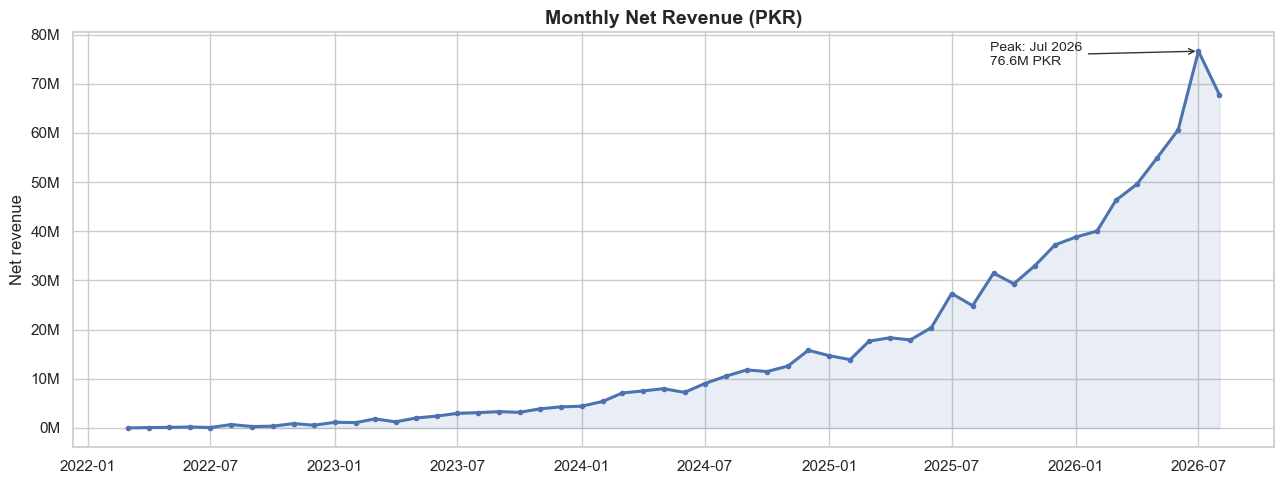

In [33]:
monthly = monthly_revenue.copy()
monthly["month"] = pd.to_datetime(monthly["month"])
peak = monthly.loc[monthly["net_revenue"].idxmax()]

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly["month"], monthly["net_revenue"], color=MAIN_COLOR, lw=2.2, marker="o", ms=3)
ax.fill_between(monthly["month"], monthly["net_revenue"], alpha=0.12, color=MAIN_COLOR)
ax.annotate(f"Peak: {peak['month']:%b %Y}\n{peak['net_revenue'] / 1e6:,.1f}M PKR",
            xy=(peak["month"], peak["net_revenue"]), xytext=(-150, -10),
            textcoords="offset points", arrowprops=dict(arrowstyle="->", color="#333"), fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_title("Monthly Net Revenue (PKR)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Net revenue")
plt.tight_layout()
plt.show()

### C.2 Category-wise revenue
**Question:** Which product categories bring in the money?
We reuse `Q3_CATEGORY_REVENUE` from Task B.

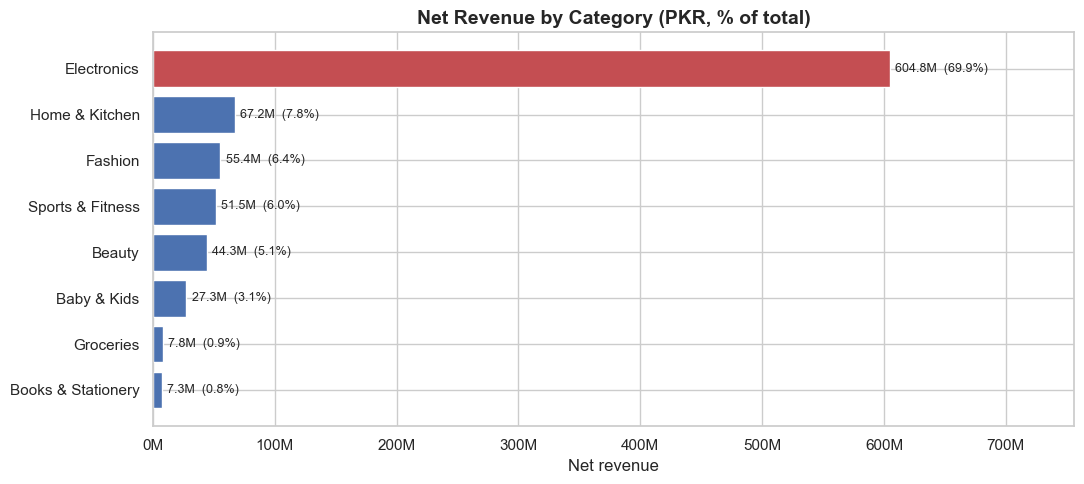

In [35]:
category_revenue = run_sql(Q3_CATEGORY_REVENUE).sort_values("net_revenue")

fig, ax = plt.subplots(figsize=(11, 5))
colors = [HIGHLIGHT_COLOR if c == category_revenue["category"].iloc[-1] else MAIN_COLOR
          for c in category_revenue["category"]]
bars = ax.barh(category_revenue["category"], category_revenue["net_revenue"], color=colors)
ax.bar_label(bars, labels=[f"{v / 1e6:,.1f}M  ({s:.1f}%)" for v, s in
                           zip(category_revenue["net_revenue"], category_revenue["revenue_share_pct"])],
             padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_xlim(0, category_revenue["net_revenue"].max() * 1.25)
ax.set_title("Net Revenue by Category (PKR, % of total)", fontsize=14, fontweight="bold")
ax.set_xlabel("Net revenue")
plt.tight_layout()
plt.show()

### C.3 City-wise revenue
**Question:** Which cities bring the most revenue, and how valuable is each customer there?
Besides total revenue, we calculate **revenue per customer**. A small city can still have very valuable customers.

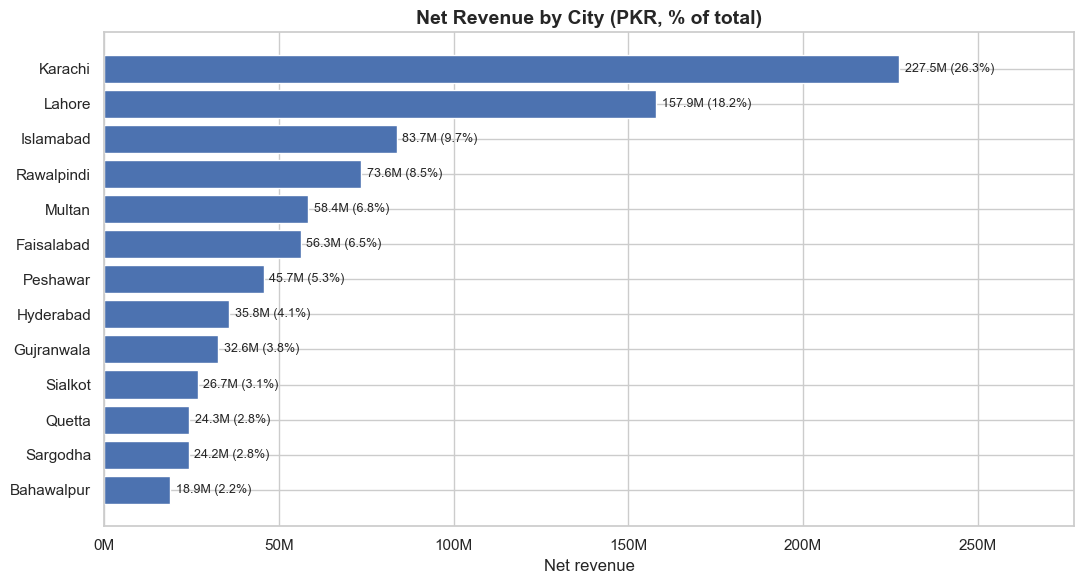

,city,customers,revenue_per_customer
11,Sargodha,141,"171,842.00"
4,Multan,430,"135,893.00"
9,Sialkot,207,"129,161.00"
12,Bahawalpur,148,"127,982.00"
3,Rawalpindi,580,"126,881.00"


In [36]:
Q_CITY_REVENUE = f"""
SELECT
    c.city,
    ROUND({NET_REVENUE_SQL}, 2)                                    AS net_revenue,
    COUNT(DISTINCT o.customer_id)                                  AS customers,
    COUNT(o.order_id)                                              AS orders,
    ROUND({NET_REVENUE_SQL} / COUNT(DISTINCT o.customer_id), 0)    AS revenue_per_customer
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.returned = 0
GROUP BY c.city
ORDER BY net_revenue DESC;
"""
city_revenue = run_sql(Q_CITY_REVENUE)
city_revenue["revenue_share_pct"] = (city_revenue["net_revenue"] / city_revenue["net_revenue"].sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(11, 6))
plot_data = city_revenue.sort_values("net_revenue")
bars = ax.barh(plot_data["city"], plot_data["net_revenue"], color=MAIN_COLOR)
ax.bar_label(bars, labels=[f"{v / 1e6:,.1f}M ({s:.1f}%)" for v, s in
                           zip(plot_data["net_revenue"], plot_data["revenue_share_pct"])],
             padding=4, fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(millions))
ax.set_xlim(0, plot_data["net_revenue"].max() * 1.22)
ax.set_title("Net Revenue by City (PKR, % of total)", fontsize=14, fontweight="bold")
ax.set_xlabel("Net revenue")
plt.tight_layout()
plt.show()

city_revenue[["city", "customers", "revenue_per_customer"]].sort_values(
    "revenue_per_customer", ascending=False).head(5)

### C.4 Return rate by product category
**Question:** Which categories have the most returns, and how much money do returns cost us?

`return_rate = returned orders ÷ all orders × 100`

Here we count **all orders** (returned and not returned), because a return rate needs both.

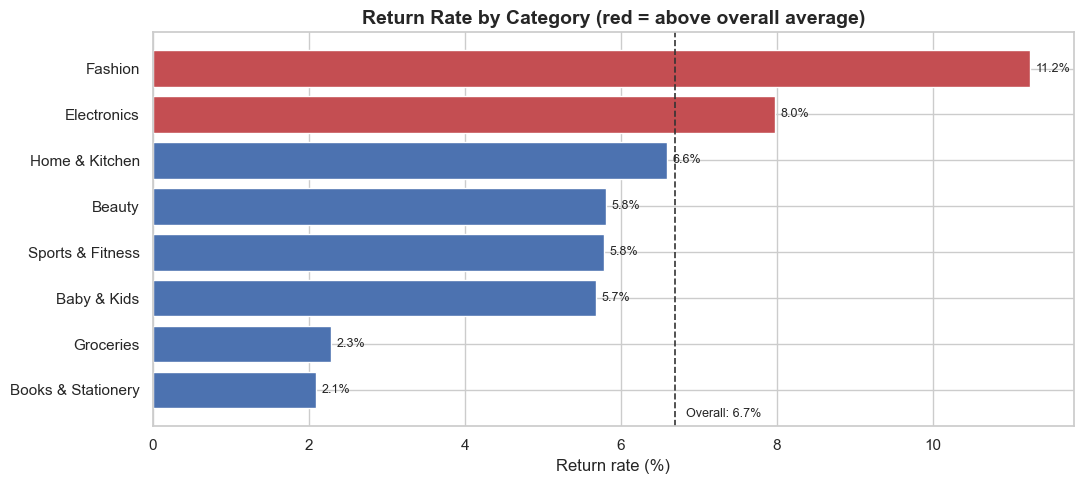

,category,total_orders,returned_orders,return_rate_pct,returned_value
0,Fashion,12242,1377,11.25,"6,819,920.18"
1,Electronics,11540,921,7.98,"51,767,601.65"
2,Home & Kitchen,7623,502,6.59,"4,751,316.73"
3,Beauty,11694,680,5.81,"2,629,479.42"
4,Sports & Fitness,7067,409,5.79,"3,038,748.45"
5,Baby & Kids,3748,213,5.68,"1,493,143.03"
6,Groceries,6088,139,2.28,"176,067.65"
7,Books & Stationery,4923,103,2.09,"161,544.49"


In [37]:
Q_RETURN_RATE = """
SELECT
    p.category,
    COUNT(o.order_id)                                       AS total_orders,
    SUM(o.returned)                                         AS returned_orders,
    ROUND(100.0 * SUM(o.returned) / COUNT(o.order_id), 2)   AS return_rate_pct,
    ROUND(SUM(CASE WHEN o.returned = 1
                   THEN o.quantity * o.unit_price * (1 - o.discount) ELSE 0 END), 2) AS returned_value
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY p.category
ORDER BY return_rate_pct DESC;
"""
return_rate = run_sql(Q_RETURN_RATE)
overall_return_rate = return_rate["returned_orders"].sum() / return_rate["total_orders"].sum() * 100

fig, ax = plt.subplots(figsize=(11, 5))
plot_data = return_rate.sort_values("return_rate_pct")
colors = [HIGHLIGHT_COLOR if r > overall_return_rate else MAIN_COLOR for r in plot_data["return_rate_pct"]]
bars = ax.barh(plot_data["category"], plot_data["return_rate_pct"], color=colors)
ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=9)
ax.axvline(overall_return_rate, color="#333", ls="--", lw=1.2)
ax.text(overall_return_rate + 0.15, -0.6, f"Overall: {overall_return_rate:.1f}%", fontsize=9)
ax.set_title("Return Rate by Category (red = above overall average)", fontsize=14, fontweight="bold")
ax.set_xlabel("Return rate (%)")
plt.tight_layout()
plt.show()

return_rate

### C.5 Key numbers behind the insights
We **calculate** every number used in the insights below, so nothing is typed by hand.

In [38]:
top_cat = category_revenue.sort_values("net_revenue", ascending=False).iloc[0]
electronics_returns = return_rate.set_index("category").loc["Electronics"]
fashion = return_rate.set_index("category").loc["Fashion"]
top2_cities = city_revenue.head(2)
best_value_city = city_revenue.sort_values("revenue_per_customer", ascending=False).iloc[0]
avg_rev_per_customer = city_revenue["net_revenue"].sum() / city_revenue["customers"].sum()
last, prev = monthly.iloc[-1], monthly.iloc[-2]
yoy_base = monthly[monthly["month"] == last["month"] - pd.DateOffset(years=1)].iloc[0]

print("1. CATEGORY CONCENTRATION")
print(f"   {top_cat['category']} = {top_cat['revenue_share_pct']:.1f}% of net revenue")
print(f"   {top_cat['category']} returns cost {electronics_returns['returned_value'] / 1e6:,.1f}M PKR = "
      f"{electronics_returns['returned_value'] / return_rate['returned_value'].sum() * 100:.1f}% of all returned value")
print("2. FASHION RETURNS")
print(f"   Fashion return rate {fashion['return_rate_pct']:.2f}% vs overall {overall_return_rate:.2f}% "
      f"({fashion['return_rate_pct'] / overall_return_rate:.1f}x higher)")
print("3. CITY CONCENTRATION AND VALUE")
print(f"   {top2_cities['city'].iloc[0]} + {top2_cities['city'].iloc[1]} = {top2_cities['revenue_share_pct'].sum():.1f}% of revenue")
print(f"   {best_value_city['city']}: {best_value_city['revenue_per_customer']:,.0f} PKR per customer "
      f"vs average {avg_rev_per_customer:,.0f} ({(best_value_city['revenue_per_customer'] / avg_rev_per_customer - 1) * 100:.0f}% higher)")
print("4. GROWTH")
print(f"   {last['month']:%b %Y} vs {prev['month']:%b %Y}: {last['mom_growth_pct']:.1f}% month-over-month")
print(f"   {last['month']:%b %Y} vs {yoy_base['month']:%b %Y}: "
      f"{(last['net_revenue'] / yoy_base['net_revenue'] - 1) * 100:.1f}% year-over-year")

1. CATEGORY CONCENTRATION
   Electronics = 69.9% of net revenue
   Electronics returns cost 51.8M PKR = 73.1% of all returned value
2. FASHION RETURNS
   Fashion return rate 11.25% vs overall 6.69% (1.7x higher)
3. CITY CONCENTRATION AND VALUE
   Karachi + Lahore = 44.5% of revenue
   Sargodha: 171,842 PKR per customer vs average 121,919 (41% higher)
4. GROWTH
   Aug 2026 vs Jul 2026: -11.6% month-over-month
   Aug 2026 vs Aug 2025: 172.4% year-over-year


Observations (short):

Electronics se 70% kamai aati hai, matlab company ek category pe depend hai, jo risky hai.
Fashion mein har 100 orders mein se 11 wapas aate hain, yani average se double. Shayad size/fitting ka masla hai.
Karachi aur Lahore se 44.5% revenue aata hai, lekin Sargodha ke customers sab se zyada kharch karte hain.
Business saal ba saal 172% barha, lekin August mein July se 11.6% kam sale hui.

## Task D: Machine Learning, Customer Churn

### D.0 What is churn and how do we set it up?
A customer **churns** when they stop buying from us. We want to predict this **before** it happens, so the business can act (discounts, reminders).

```
 ◄────────── HISTORY (features) ──────────►│◄──── TARGET WINDOW ────►
            all orders up to 31 May 2026    │   1 Jun – 31 Aug 2026
                                            │
   "What did the customer do before?"       │  "Did they buy again?"
                                            │   no order  → churn = 1
                                            │   any order → churn = 0
```

**Who is included:** only customers with at least one order on or before 31 May 2026.

**How we avoid data leakage:**
1. Features use **only orders up to 31 May 2026**. Nothing from the target window is used as a feature.
2. Missing values are filled and data is scaled **inside a Pipeline**, which learns only from the training set.
3. The test set is used **once**, for the final evaluation.
4. `customer_id` is **not** a feature. It is just an ID and has no real meaning.

In [40]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)

RANDOM_STATE = 42
FEATURE_CUTOFF = "2026-05-31"
TARGET_START, TARGET_END = "2026-06-01", "2026-08-31"

In [41]:
CHURN_DATASET_SQL = """
WITH history AS (
    SELECT * FROM orders WHERE order_date <= :cutoff
),
features AS (
    SELECT
        customer_id,
        COUNT(*)                                                             AS total_orders,
        SUM(CASE WHEN returned = 0
                 THEN quantity * unit_price * (1 - discount) ELSE 0 END)     AS total_spending,
        AVG(quantity * unit_price * (1 - discount))                          AS avg_order_value,
        CAST(julianday(:cutoff) - julianday(MAX(order_date)) AS INTEGER)     AS days_since_last_order,
        AVG(returned)                                                        AS return_rate,
        AVG(delivery_days)                                                   AS avg_delivery_days
    FROM history
    GROUP BY customer_id
),
active_in_target AS (
    SELECT DISTINCT customer_id
    FROM orders
    WHERE order_date BETWEEN :target_start AND :target_end
)
SELECT
    f.*,
    c.age,
    c.membership_type,
    CASE WHEN a.customer_id IS NULL THEN 1 ELSE 0 END AS churn
FROM features f
JOIN customers c        ON f.customer_id = c.customer_id
LEFT JOIN active_in_target a ON f.customer_id = a.customer_id;
"""

churn_df = pd.read_sql(CHURN_DATASET_SQL, clean_conn, params={
    "cutoff": FEATURE_CUTOFF, "target_start": TARGET_START, "target_end": TARGET_END})

print("Customers in churn dataset:", churn_df.shape[0])
print("Columns:", churn_df.shape[1])
churn_df.head()

Customers in churn dataset: 6536
Columns: 10


,customer_id,total_orders,total_spending,avg_order_value,days_since_last_order,return_rate,avg_delivery_days,age,membership_type,churn
0,2,3,"6,229.50","2,076.50",3,0.00,4.67,33.00,Silver,0
1,3,6,"24,102.46","4,017.08",107,0.00,3.17,25.00,Standard,1
2,4,5,"14,400.81","2,880.16",13,0.00,3.00,26.00,Standard,1
3,5,8,"76,312.81","9,539.10",19,0.00,3.50,27.00,Standard,0
4,6,3,"50,020.16","16,673.39",440,0.00,3.00,24.00,Standard,1


### D.2 Check the target and missing values
Before choosing models, we check two things:
- **Class balance:** if only 5% of customers churned, accuracy would be misleading and we would need special handling.
- **Missing values:** so we know what the pipeline must fill.

In [42]:
churn_counts = churn_df["churn"].value_counts().rename({0: "Stayed (0)", 1: "Churned (1)"})
churn_share = (churn_counts / churn_counts.sum() * 100).round(2)
display(pd.DataFrame({"customers": churn_counts, "percent": churn_share}))

print("Missing values per column:")
missing = churn_df.isna().sum()
print(missing[missing > 0].to_string())

churn_df.drop(columns="customer_id").describe().T

,customers,percent
churn,,
Stayed (0),3331,50.96
Churned (1),3205,49.04


Missing values per column:
age    87


,count,mean,std,min,25%,50%,75%,max
total_orders,"6,536.00",7.60,10.43,1.00,2.00,3.00,8.00,57.00
total_spending,"6,536.00","101,078.06","169,487.07",0.00,"4,996.35","22,654.38","121,648.96","1,357,083.63"
avg_order_value,"6,536.00","14,526.99","26,234.26",71.06,"2,838.73","7,178.91","15,933.39","607,688.29"
days_since_last_order,"6,536.00",139.65,188.74,0.00,19.00,64.00,183.00,"1,372.00"
return_rate,"6,536.00",0.07,0.16,0.00,0.00,0.00,0.06,1.00
avg_delivery_days,"6,536.00",3.60,1.07,1.00,3.00,3.50,4.20,9.00
age,"6,449.00",30.81,8.38,18.00,24.00,31.00,37.00,65.00
churn,"6,536.00",0.49,0.50,0.00,0.00,0.00,1.00,1.00


**Result:** the classes are almost **50 / 50**, so the data is **balanced**.
We do **not** need SMOTE or class weights. Adding them would only be "using a technique because it is popular".

Only `age` has missing values (customers with no age in the customers table). The pipeline fills them with the **median of the training data**.

In [43]:
NUMERIC_FEATURES = ["total_orders", "total_spending", "avg_order_value", "days_since_last_order",
                    "return_rate", "avg_delivery_days", "age"]
CATEGORICAL_FEATURES = ["membership_type"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = "churn"

X = churn_df[FEATURES]
y = churn_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print("Train:", X_train.shape, "| churn rate:", round(y_train.mean() * 100, 2), "%")
print("Test: ", X_test.shape, "| churn rate:", round(y_test.mean() * 100, 2), "%")

Train: (5228, 8) | churn rate: 49.04 %
Test:  (1308, 8) | churn rate: 49.01 %


In [54]:
# D.4 Preprocessing pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


def make_preprocessor(scale_numeric):
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scale", StandardScaler()))
    return ColumnTransformer([
        ("num", Pipeline(numeric_steps), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ])


models = {
    "Logistic Regression": Pipeline([
        ("preprocess", make_preprocessor(scale_numeric=True)),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline([
        ("preprocess", make_preprocessor(scale_numeric=False)),
        ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                         random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
}

print("Models ready:", list(models.keys()))

Models ready: ['Logistic Regression', 'Random Forest']


In [55]:
# D.5 Train and compare the models
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def evaluate(name, model, X_eval, y_eval):
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {"model": name,
            "accuracy": accuracy_score(y_eval, pred),
            "precision": precision_score(y_eval, pred),
            "recall": recall_score(y_eval, pred),
            "f1": f1_score(y_eval, pred),
            "roc_auc": roc_auc_score(y_eval, proba)}


results, test_probas = [], {}
for name, model in models.items():
    cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc")
    model.fit(X_train, y_train)
    row = evaluate(name, model, X_test, y_test)
    row["cv_roc_auc"] = f"{cv_auc.mean():.3f} ± {cv_auc.std():.3f}"
    row["train_roc_auc"] = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    results.append(row)
    test_probas[name] = model.predict_proba(X_test)[:, 1]

comparison = pd.DataFrame(results).set_index("model").round(3)
with pd.option_context("display.float_format", "{:.3f}".format):
    display(comparison)

,accuracy,precision,recall,f1,roc_auc,cv_roc_auc,train_roc_auc
model,,,,,,,
Logistic Regression,0.721,0.672,0.841,0.747,0.785,0.767 ± 0.018,0.770
Random Forest,0.719,0.680,0.803,0.737,0.783,0.758 ± 0.019,0.956


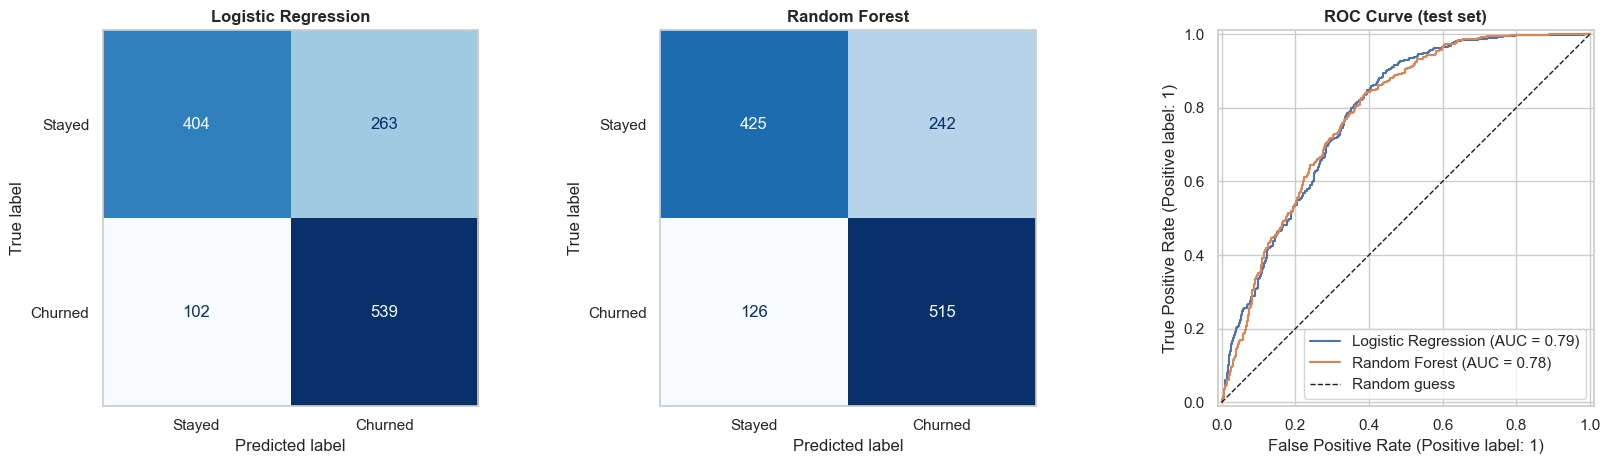

In [56]:
# D.6 Confusion matrices and ROC curves
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (name, model) in zip(axes[:2], models.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=["Stayed", "Churned"],
                                          cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(name, fontweight="bold")
    ax.grid(False)

for name, proba in test_probas.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[2])
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="Random guess")
axes[2].set_title("ROC Curve (test set)", fontweight="bold")
axes[2].legend(loc="lower right")
plt.tight_layout()
plt.show()

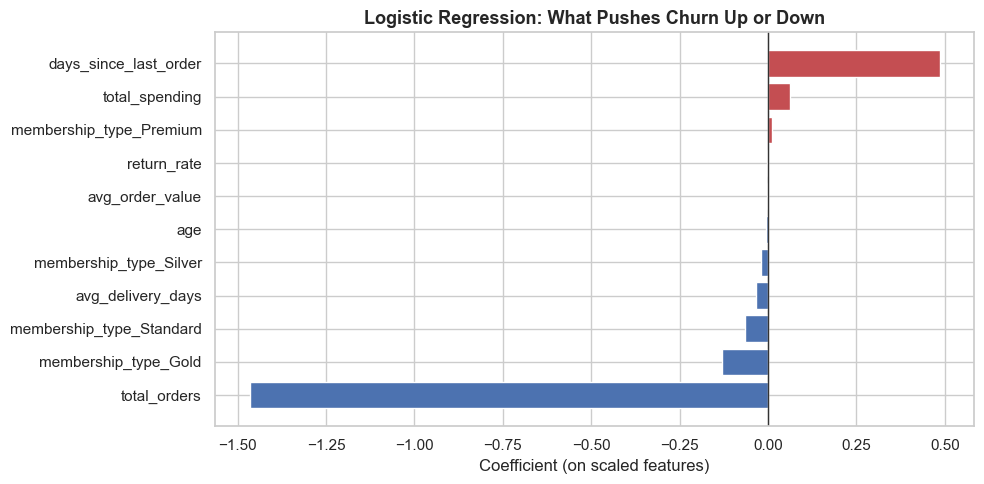

In [57]:
# D.7 Logistic Regression coefficients
MAIN_COLOR, HIGHLIGHT_COLOR = "#4C72B0", "#C44E52"

lr_pipeline = models["Logistic Regression"]
coefficients = pd.Series(
    lr_pipeline.named_steps["model"].coef_[0],
    index=lr_pipeline.named_steps["preprocess"].get_feature_names_out()
).rename(lambda s: s.split("__")[1]).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(coefficients.index, coefficients.values,
        color=[HIGHLIGHT_COLOR if v > 0 else MAIN_COLOR for v in coefficients.values])
ax.axvline(0, color="#333", lw=1)
ax.set_title("Logistic Regression: What Pushes Churn Up or Down", fontsize=13, fontweight="bold")
ax.set_xlabel("Coefficient (on scaled features)")
plt.tight_layout()
plt.show()

In [58]:
# D.8 Which model do we choose?
lr_row, rf_row = comparison.loc["Logistic Regression"], comparison.loc["Random Forest"]
print(f"{'':<22}{'Log. Regression':>17}{'Random Forest':>16}")
for metric in ["roc_auc", "f1", "recall", "precision", "accuracy", "train_roc_auc"]:
    print(f"{metric:<22}{lr_row[metric]:>17.3f}{rf_row[metric]:>16.3f}")
print(f"{'overfitting gap':<22}{lr_row['train_roc_auc'] - lr_row['roc_auc']:>17.3f}"
      f"{rf_row['train_roc_auc'] - rf_row['roc_auc']:>16.3f}")

                        Log. Regression   Random Forest
roc_auc                           0.785           0.783
f1                                0.747           0.737
recall                            0.841           0.803
precision                         0.672           0.680
accuracy                          0.721           0.719
train_roc_auc                     0.770           0.956
overfitting gap                  -0.015           0.173


In [59]:
# D.9 Save the final model
import os, joblib, json

os.makedirs("models", exist_ok=True)
CHURN_MODEL_PATH = "models/churn_model.joblib"
joblib.dump(lr_pipeline, CHURN_MODEL_PATH)

churn_metadata = {
    "model": "Logistic Regression",
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "membership_types": sorted(churn_df["membership_type"].unique().tolist()),
    "feature_cutoff": FEATURE_CUTOFF,
    "target_window": [TARGET_START, TARGET_END],
    "test_metrics": comparison.loc["Logistic Regression", ["accuracy", "precision", "recall", "f1", "roc_auc"]].to_dict(),
}
with open("models/churn_metadata.json", "w") as f:
    json.dump(churn_metadata, f, indent=2)

reloaded = joblib.load(CHURN_MODEL_PATH)
sample = X_test.iloc[[0]]
print("Saved:", CHURN_MODEL_PATH)
print("Reloaded model prediction for one customer:",
      reloaded.predict(sample)[0], "| churn probability:", round(reloaded.predict_proba(sample)[0, 1], 3))

Saved: models/churn_model.joblib
Reloaded model prediction for one customer: 0 | churn probability: 0.402


In [60]:
# E.1 Setup and preprocessing
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hide TensorFlow info messages

import numpy as np
import tensorflow as tf
from tensorflow import keras

tf.keras.utils.set_random_seed(RANDOM_STATE)   # same results every run

# Same preprocessing as Logistic Regression, fitted on training data only
nn_preprocessor = make_preprocessor(scale_numeric=True)
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)
print("Input features after preprocessing:", X_train_nn.shape[1])

C:\Users\Dell\anaconda3\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Input features after preprocessing: 11


In [61]:
# E.2 Build the network: 32 -> 16 -> 1
def build_churn_nn(n_inputs):
    model = keras.Sequential([
        keras.layers.Input(shape=(n_inputs,)),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy",
                  metrics=[keras.metrics.AUC(name="auc")])
    return model

nn_model = build_churn_nn(X_train_nn.shape[1])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

Training stopped after 23 epochs | best epoch: 13


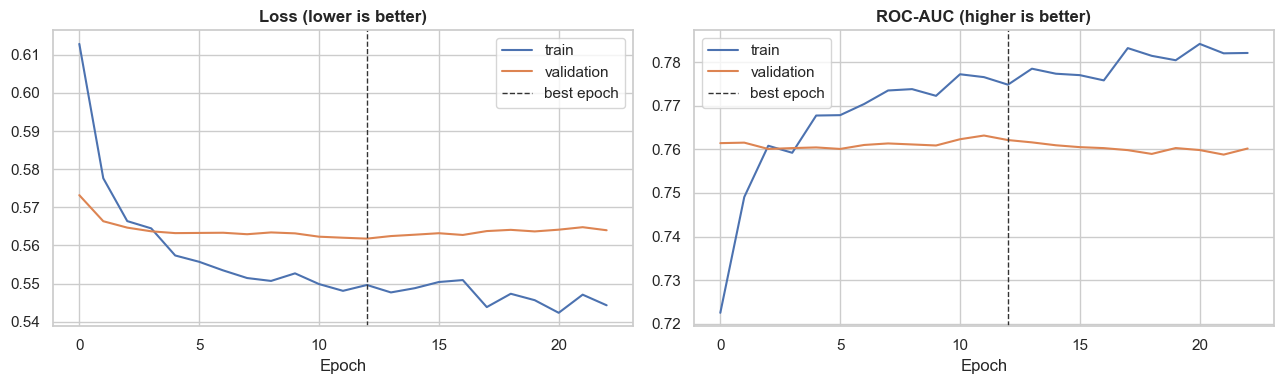

In [62]:
# E.3 Train with early stopping
import matplotlib.pyplot as plt

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = nn_model.fit(
    X_train_nn, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0,
)
best_epoch = int(np.argmin(history.history["val_loss"])) + 1
print(f"Training stopped after {len(history.history['loss'])} epochs | best epoch: {best_epoch}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric, title in [(axes[0], "loss", "Loss (lower is better)"),
                          (axes[1], "auc", "ROC-AUC (higher is better)")]:
    ax.plot(history.history[metric], label="train")
    ax.plot(history.history[f"val_{metric}"], label="validation")
    ax.axvline(best_epoch - 1, color="#333", ls="--", lw=1, label="best epoch")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

In [63]:
# E.4 Evaluate on the same test set and compare with Task D
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

nn_proba = nn_model.predict(X_test_nn, verbose=0).ravel()
nn_pred = (nn_proba >= 0.5).astype(int)

nn_row = {"model": "Neural Network (32-16-1)",
          "accuracy": accuracy_score(y_test, nn_pred),
          "precision": precision_score(y_test, nn_pred),
          "recall": recall_score(y_test, nn_pred),
          "f1": f1_score(y_test, nn_pred),
          "roc_auc": roc_auc_score(y_test, nn_proba)}

all_models = pd.concat([
    comparison[["accuracy", "precision", "recall", "f1", "roc_auc"]],
    pd.DataFrame([nn_row]).set_index("model"),
])
all_models["model_size"] = [
    lr_pipeline.named_steps["model"].coef_.size + 1,
    sum(est.tree_.node_count for est in models["Random Forest"].named_steps["model"].estimators_),
    nn_model.count_params(),
]
print(all_models.round(3).to_string())

                          accuracy  precision  recall   f1  roc_auc  model_size
model                                                                          
Logistic Regression           0.72       0.67    0.84 0.75     0.79          12
Random Forest                 0.72       0.68    0.80 0.74     0.78      251886
Neural Network (32-16-1)      0.72       0.66    0.87 0.75     0.79         929


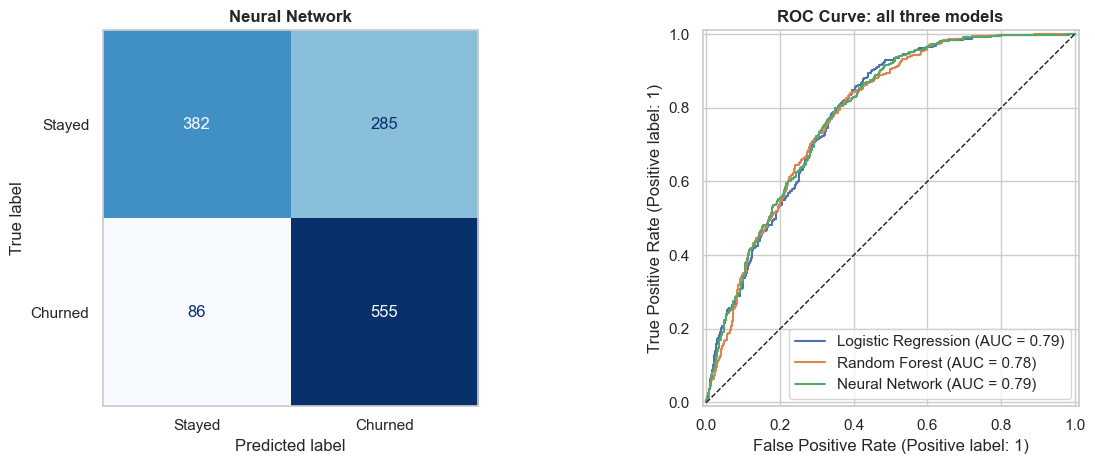

In [64]:
# E.5 Confusion matrix and ROC curves for all models
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ConfusionMatrixDisplay.from_predictions(y_test, nn_pred, display_labels=["Stayed", "Churned"],
                                        cmap="Blues", colorbar=False, ax=axes[0])
axes[0].set_title("Neural Network", fontweight="bold")
axes[0].grid(False)

for name, proba in {**test_probas, "Neural Network": nn_proba}.items():
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC Curve: all three models", fontweight="bold")
axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

In [65]:
# E.6 Was Deep Learning worth it?
lr_auc = all_models.loc["Logistic Regression", "roc_auc"]
nn_auc = all_models.loc["Neural Network (32-16-1)", "roc_auc"]
lr_size = all_models.loc["Logistic Regression", "model_size"]
nn_size = all_models.loc["Neural Network (32-16-1)", "model_size"]

print(f"ROC-AUC  Logistic Regression: {lr_auc:.3f} | Neural Network: {nn_auc:.3f} | difference: {nn_auc - lr_auc:+.3f}")
print(f"Parameters  Logistic Regression: {lr_size} | Neural Network: {nn_size} | {nn_size / lr_size:.0f}x more")

ROC-AUC  Logistic Regression: 0.785 | Neural Network: 0.787 | difference: +0.002
Parameters  Logistic Regression: 12 | Neural Network: 929 | 77x more


**No, Deep Learning was not worth the extra complexity here.**
The neural network reached almost the **same ROC-AUC as Logistic Regression** while using about **77× more parameters** (929 vs 12), needing a training loop with early stopping, and being much harder to explain.
With only **8 simple tabular features** and about **5,000 training customers**, the patterns are mostly simple (recent and frequent buyers stay), so a linear model already captures them. Neural networks shine with large data or unstructured inputs like text and images, not small tables like this one.

## Task F: NLP, Review Sentiment Analysis

**Goal:** read a customer review and predict whether it is **Negative, Neutral or Positive**.

**Plan:**
1. Load the cleaned reviews and create labels from the rating
2. Check the text for problems (duplicates, mixed languages)
3. Prepare the text
4. Split train/test **without letting the same review text appear in both**
5. TF-IDF + Logistic Regression
6. Evaluate with Accuracy, Precision, Recall, F1
7. Test it on brand-new sentences and write the limitation

Unusable reviews (empty text, ratings outside 1–5) were **already removed in Task A**, so we start from clean records.

In [66]:
# F.1 Load reviews and create sentiment labels (in SQL)
import os, json, joblib
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, ConfusionMatrixDisplay)

SENTIMENT_LABELS = ["Negative", "Neutral", "Positive"]

reviews_df = run_sql("""
    SELECT review_id,
           rating,
           review_text,
           CASE WHEN rating <= 2 THEN 'Negative'
                WHEN rating = 3  THEN 'Neutral'
                ELSE 'Positive' END AS sentiment
    FROM reviews;
""")

label_counts = reviews_df["sentiment"].value_counts().reindex(SENTIMENT_LABELS)
print("Reviews:", len(reviews_df))
pd.DataFrame({"reviews": label_counts, "percent": (label_counts / label_counts.sum() * 100).round(2)})

Reviews: 25885


,reviews,percent
sentiment,,
Negative,2006,7.75
Neutral,5458,21.09
Positive,18421,71.16


In [67]:
# F.2 Check the text before modelling
unique_texts = reviews_df["review_text"].nunique()
print(f"Total reviews:        {len(reviews_df):,}")
print(f"Unique review texts:  {unique_texts:,}")
print(f"Repeated texts:       {len(reviews_df) - unique_texts:,} ({(1 - unique_texts / len(reviews_df)) * 100:.1f}% of reviews)")

roman_urdu = reviews_df["review_text"].str.contains(r"\b(?:hai|thi|bohat|theek|kharab|mili|nikla)\b", case=False)
print(f"Reviews with Roman Urdu words: {roman_urdu.sum():,} ({roman_urdu.mean() * 100:.1f}%)")

print("\nMost repeated review texts:")
reviews_df["review_text"].value_counts().head(5)

Total reviews:        25,885
Unique review texts:  4,484
Repeated texts:       21,401 (82.7% of reviews)
Reviews with Roman Urdu words: 2,600 (10.0%)

Most repeated review texts:


review_text
I would buy this again, overall value is strong. Highly recommended.               35
Really happy with this purchase, works exactly as expected. Highly recommended.    34
Really happy with this purchase, delivery was on time. Satisfied with my order.    33
Very satisfied, overall value is strong. Recommended for others.                   33
I would buy this again, size and color were correct. Will order again.             32
Name: count, dtype: int64

### F.3 Prepare the text
We let `TfidfVectorizer` do the cleaning, so the **exact same steps** run in the notebook and inside the Streamlit app:

| Step | Setting | Why |
|---|---|---|
| Lowercase | `lowercase=True` | "Good" and "good" are the same word |
| Keep only words of 2+ letters | `token_pattern` | removes punctuation, numbers and single letters |
| **No stopword removal** | (default) | English stopword lists remove **"not"**, which flips meaning: *"not good"* would become *"good"* |
| Word pairs (bigrams) | `ngram_range=(1, 2)` | catches phrases like *"not satisfied"* and *"would not"* |
| Ignore very rare words | `min_df=2` | a word seen only once is usually noise |
| Dampen repeated words | `sublinear_tf=True` | a word used 5 times is not 5× more important |

**Why TF-IDF?** It gives a high weight to words that are frequent **in this review** but rare **across all reviews**. Common words like "the" get a low weight, while words like "disappointing" or "premium" get a high weight.

In [72]:
# F.3 Text preparation settings + preview
TFIDF_SETTINGS = dict(lowercase=True, token_pattern=r"\b[a-z]{2,}\b",
                      ngram_range=(1, 2), min_df=2, sublinear_tf=True)

# Show what the model actually "sees" after text preparation
analyzer = TfidfVectorizer(**{**TFIDF_SETTINGS, "ngram_range": (1, 1)}).build_analyzer()
examples = reviews_df.loc[roman_urdu, "review_text"].head(2).tolist() + ["Not good!! Would NOT buy again... 0/10"]
for text in examples:
    print("ORIGINAL:", text)
    print("TOKENS:  ", analyzer(text), "\n")

ORIGINAL: Very satisfied, seller description was accurate. Good value for money. product bilkul theek nikla
TOKENS:   ['very', 'satisfied', 'seller', 'description', 'was', 'accurate', 'good', 'value', 'for', 'money', 'product', 'bilkul', 'theek', 'nikla'] 

ORIGINAL: Decent but could be better, support response was slow. No strong opinion. theek hai lekin average quality
TOKENS:   ['decent', 'but', 'could', 'be', 'better', 'support', 'response', 'was', 'slow', 'no', 'strong', 'opinion', 'theek', 'hai', 'lekin', 'average', 'quality'] 

ORIGINAL: Not good!! Would NOT buy again... 0/10
TOKENS:   ['not', 'good', 'would', 'not', 'buy', 'again'] 



In [73]:
# F.4 Train/test split by unique text
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(reviews_df, groups=reviews_df["review_text"]))
reviews_train, reviews_test = reviews_df.iloc[train_idx], reviews_df.iloc[test_idx]

overlap = reviews_test["review_text"].isin(reviews_train["review_text"]).sum()
print(f"Train reviews: {len(reviews_train):,} | Test reviews: {len(reviews_test):,}")
print(f"Test texts also found in train: {overlap}  (must be 0)")

pd.DataFrame({
    "train_%": reviews_train["sentiment"].value_counts(normalize=True).reindex(SENTIMENT_LABELS) * 100,
    "test_%": reviews_test["sentiment"].value_counts(normalize=True).reindex(SENTIMENT_LABELS) * 100,
}).round(2)

Train reviews: 20,661 | Test reviews: 5,224
Test texts also found in train: 0  (must be 0)


,train_%,test_%
sentiment,,
Negative,7.54,8.58
Neutral,21.33,20.12
Positive,71.13,71.31


In [77]:
# F.5 Train TF-IDF + Logistic Regression
sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(**TFIDF_SETTINGS)),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
sentiment_model.fit(reviews_train["review_text"], reviews_train["sentiment"])

vocab_size = len(sentiment_model.named_steps["tfidf"].vocabulary_)
print(f"Vocabulary learned from training reviews: {vocab_size:,} words and word pairs")

Vocabulary learned from training reviews: 978 words and word pairs


### F.6 Evaluate
- **Accuracy:** % of reviews labelled correctly
- **Precision:** when the model says "Negative", how often is it right?
- **Recall:** of all truly Negative reviews, how many did it find?
- **F1:** balance of precision and recall
- **Macro average:** each class counts equally, so the small Negative class matters as much as Positive

**Result:** the model is **perfect on the test set**, even with the strict split where no test text was seen in training.

**Should we trust 100%?** Not fully. The reviews are built from a **small set of template phrases** ("Very satisfied…", "Would not buy again…").
Even unseen reviews reuse the same phrases, so the task is easy **for this dataset**. The next cell checks how the model handles **real-world wording**.

accuracy          1.00
precision_macro   1.00
recall_macro      1.00
f1_macro          1.00 

              precision    recall  f1-score   support

    Negative      1.000     1.000     1.000       448
     Neutral      1.000     1.000     1.000      1051
    Positive      1.000     1.000     1.000      3725

    accuracy                          1.000      5224
   macro avg      1.000     1.000     1.000      5224
weighted avg      1.000     1.000     1.000      5224



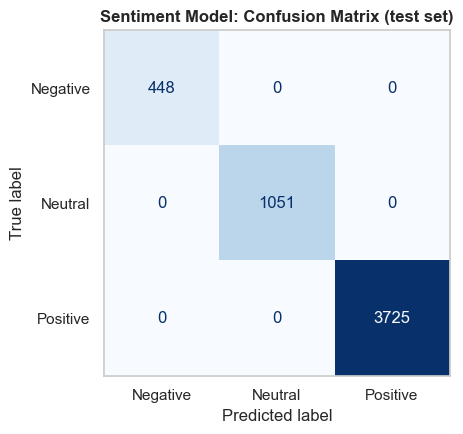

In [79]:
# F.6 Evaluate on the test set
sentiment_pred = sentiment_model.predict(reviews_test["review_text"])

sentiment_scores = pd.Series({
    "accuracy": accuracy_score(reviews_test["sentiment"], sentiment_pred),
    "precision_macro": precision_score(reviews_test["sentiment"], sentiment_pred, average="macro"),
    "recall_macro": recall_score(reviews_test["sentiment"], sentiment_pred, average="macro"),
    "f1_macro": f1_score(reviews_test["sentiment"], sentiment_pred, average="macro"),
}).round(3)
print(sentiment_scores.to_string(), "\n")
print(classification_report(reviews_test["sentiment"], sentiment_pred, labels=SENTIMENT_LABELS, digits=3))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(reviews_test["sentiment"], sentiment_pred, labels=SENTIMENT_LABELS,
                                        cmap="Blues", colorbar=False, ax=ax)
ax.set_title("Sentiment Model: Confusion Matrix (test set)", fontweight="bold")
ax.grid(False)
plt.tight_layout()
plt.show()

In [80]:
# F.7 Stress test on brand-new sentences
new_reviews = [
    "Very satisfied, quality feels premium.",          # template-style positive
    "Would not buy again, packaging was damaged.",     # template-style negative
    "quality bohat kharab thi",                        # Roman Urdu negative
    "I love it",                                       # real-world positive
    "It broke after two days",                         # real-world negative
    "Not bad at all, I really liked it",               # tricky negation
]
stress_test = pd.DataFrame({"review": new_reviews, "predicted": sentiment_model.predict(new_reviews)})
stress_test["confidence"] = sentiment_model.predict_proba(new_reviews).max(axis=1).round(2)
stress_test

,review,predicted,confidence
0,"Very satisfied, quality feels premium.",Positive,0.92
1,"Would not buy again, packaging was damaged.",Negative,0.99
2,quality bohat kharab thi,Negative,0.70
3,I love it,Neutral,0.82
4,It broke after two days,Neutral,0.82
5,"Not bad at all, I really liked it",Neutral,0.75


**How to read it:** template-style sentences and the Roman Urdu phrase are predicted correctly.
But simple real-world sentences like *"I love it"* or *"It broke after two days"* use words the model **never saw** in training, so it falls back to **Neutral**, and it is even fairly confident (~0.8). A wrong answer given with confidence is risky in a real app.

### F.8 Limitation
**The review dataset is template-generated:** about 83% of reviews are exact repeats, and they are built from a small vocabulary of fixed phrases.
The model learns these phrases almost perfectly (100% on the test set), but it **does not generalize well to real customer language**. New words, slang, sarcasm and negations like *"not bad at all"* are often labelled Neutral.

A second limitation comes from the **labels**: sentiment is taken from the star rating, not from the text. A customer could write a positive text but give 3 stars (Neutral), so the label may not always match what the text says.

**Fix with more time:** collect real, varied reviews (with more Roman Urdu), or use a pretrained multilingual language model that already understands everyday words.

In [81]:
# F.9 Save the sentiment model
os.makedirs("models", exist_ok=True)
SENTIMENT_MODEL_PATH = "models/sentiment_model.joblib"
joblib.dump(sentiment_model, SENTIMENT_MODEL_PATH)

with open("models/sentiment_metadata.json", "w") as f:
    json.dump({"model": "TF-IDF + Logistic Regression",
               "labels": {"Negative": "rating 1-2", "Neutral": "rating 3", "Positive": "rating 4-5"},
               "test_metrics": sentiment_scores.to_dict()}, f, indent=2)

reloaded_sentiment = joblib.load(SENTIMENT_MODEL_PATH)
print("Saved:", SENTIMENT_MODEL_PATH)
print("Reloaded model test:", reloaded_sentiment.predict(["Very satisfied, good value for money"])[0])

Saved: models/sentiment_model.joblib
Reloaded model test: Positive


Observation
"Hamara model 100% accurate aaya, lekin humne us pe blindly trust nahi kiya. Humne check kiya to 83% reviews copy-paste templates nikle. Phir humne split aisa kiya ke same review train aur test dono mein na aaye. Score phir bhi 100% raha, kyun ke reviews ek hi jaise phrases use karte hain. Phir humne naye sentences pe test kiya: 'I love it' ko model ne Neutral bola. Yeh hamari limitation hai: model sirf is dataset ki language samajhta hai, real customers ki nahi."